In [1]:
import pandas as pd
from datetime import datetime
import numpy as np

Read DataBase

In [2]:
df_games = pd.read_parquet('last_games.parquet')
df_ranking = pd.read_parquet('ranking_fifa.parquet')
df_teams = pd.read_parquet('teams.parquet')

df_games.sample(5)

,Seleccion,Fecha,Tipo_Partido,Venue,Condicion,Oponente,Goles_Equipo,Goles_Rival,Resultado_Original,Es_Penales,Es_Tiempo_Extra
1957,NED,2023-09-07,UEFA Euro 2024 qualifying,"Eindhoven , Netherlands",L,Greece,3.0,0.0,3–0,False,False
58,COL,2024-06-15,Friendly,"Empower Field at Mile High, Denver (N)",N,Bolivia,3.0,0.0,3–0,False,False
1627,NOR,2023-06-17,UEFA Euro 2024 qualifying,"Oslo , Norway",L,Scotland,1.0,2.0,1–2,False,False
522,JPN,2025-11-14,Kirin Challenge Cup,"Toyota , Japan",L,Ghana,2.0,0.0,2–0,False,False
543,JOR,2024-01-29,Asian Cup round of 16,"Al Rayyan , Qatar",N,Iraq,3.0,2.0,2–3,False,False


Limpieza - Selecciones Asociadas

In [3]:
# 2. Definir mapa de nombres (Wikipedia -> Código FIFA)
mapa_nombres = {
    'United States': 'USA',
    'South Korea': 'KOR',
    'DR Congo': 'COD',
    'Ivory Coast': 'CIV',
    'Turkey': 'TUR',
    'China': 'CHN',
    'Iran': 'IRN',
    'North Korea': 'PRK',
    'Kyrgyzstan': 'KGZ',
    'Czech Republic': 'CZE',
    'Cape Verde': 'CPV',
    'Gambia': 'GAM',
    'Saint Kitts and Nevis':'SKN',
    'Saint Lucia':'LCA'
}

mapa_fifa = df_ranking.set_index('Seleccion')['Codigo_Pais'].to_dict()
mapa_final = mapa_nombres | mapa_fifa

# 3. Aplicar limpieza
# Filtramos primero los que queremos eliminar
df_limpio = df_games.copy()

# Mapeamos los nombres a códigos FIFA
df_limpio['Codigo_Pais'] = df_limpio['Oponente'].map(mapa_final)

# Los que sigan siendo NaN aquí son los que no están en tu diccionario 
# o son selecciones que quizás no quieres incluir (como Saint Kitts, etc.)
df_limpio = df_limpio[df_limpio['Codigo_Pais'].notna()&df_limpio['Goles_Equipo'].notna()].copy()

Limpieza - Tipo de Torneos

In [4]:
federaciones = {
    'UEFA': ['ESP', 'FRA', 'GER', 'ENG', 'ITA', 'POR','AUT','NOR','SWE','NED',
            'BEL', 'BIH', 'CRO', 'CZE', 'SCO', 'SUI', 'TUR'], # Agrega todos los necesarios
    'CONCACAF': ['USA', 'MEX', 'CAN', 'CRC', 'PAN', 'CUW','HAI'],
    'CONMEBOL': ['URU', 'ARG', 'BRA', 'CHI', 'COL'],
    'AFC': ['IRN', 'UZB'],    
    # ... resto de confederaciones
}

def obtener_confederacion(codigo_pais):
    for conf, paises in federaciones.items():
        if codigo_pais in paises:
            return conf
    return 'Otra'

In [5]:
def clasificar_torneo_fila(row):
    nombre = str(row['Tipo_Partido']).lower()
    cod_pais = row['Seleccion']
    confederacion = obtener_confederacion(cod_pais) 
    fecha = pd.to_datetime(row['Fecha'])   
        
    # Orden de prioridad: de lo más específico a lo más general
    if any(x in nombre for x in ['world cup']) and (fecha >= datetime(2026, 6, 10) and fecha <= datetime(2026, 7, 31)):
        return 'World Cup'
    if any(x in nombre for x in ['copa américa', 'copa america']):
        return 'America Cup'
    if any(x in nombre for x in ['afc asian cup', 'asian cup', '20cup gs']):
        return 'Asian Cup'
    if any(x in nombre for x in ['afcon', 'africa cup']):
        return 'African Cup'
    if any(x in nombre for x in ['ofc']):
        return 'Oceanic Cup'    
    if any(x in nombre for x in ['euro', 'european championship']):
        return 'European Cup'
    if any(x in nombre for x in ['gold cup', 'concacaf gold']):
        return 'Gold Cup'
    if any(x in nombre for x in ['nations league','–league', 'uefa nl', 'cafa nations cup']):
        return f"{confederacion} - Nations League"
    if any(x in nombre for x in ['fifa arab','arab cup']):
        return 'Arab Cup'
    if any(x in nombre for x in ['friendly', 'blue dream match', 'heritage match', 'world cup warm-up']):
        return 'Friendly'
    if any(x in nombre for x in ['world cup qualification', 'wcq', 'fifa world cup q', 'world cup qualifiers', 
            '2026 world cup q', 'world cup q', 'fifa world cup (qualification)','2026 fwc q','fifa wc qualifier',
            'fifa wc qualification', '2026 wc qualif']):
        return 'WC Qualifiers'
    return 'Other'

# Aplicar al DataFrame
df_limpio['Tipo_Partido_Limpio'] = df_limpio.apply(clasificar_torneo_fila, axis=1)

Insert Lost Games and Rename Column Names

In [6]:
df_lost = pd.read_excel('OtherGames.xlsx')
df_lost['Fecha'] = df_lost['Fecha'].dt.strftime("%Y-%m-%d")
df_final = pd.concat([df_limpio, df_lost], axis=0)
df_final.rename(columns={'Codigo_Pais':'Opponent', 'Seleccion':'Team', 
        'Condicion':'Condition', 'Goles_Equipo':'Goals_team', 
        'Goles_Rival':'Goals_opponent', 'Es_Penales':'Penalties', 
        'Es_Tiempo_Extra':'AET', 'Fecha':'Date',
        'Tipo_Partido_Limpio':'Game_type'}, inplace=True)

In [7]:
df_final[['Date', 'Game_type', 'Condition', 'Team', 'Goals_team', 
        'Opponent', 'Goals_opponent', 'Penalties', 'AET']].to_parquet('Games_list.parquet', index=False)

Variables to Model

In [8]:
def calcular_decaimiento_exponencial(df, alpha=0.05):
    """
    Asigna un peso a cada partido basado en qué tan reciente es.
    alpha: tasa de decaimiento (ajustar según qué tan rápido pierden relevancia los datos viejos).
    """
    df['Date'] = pd.to_datetime(df['Date'])
    fecha_final = datetime(2026, 7, 20)
    df['Final_days'] = (fecha_final - df['Date']).dt.days
    df['Date_decay'] = np.exp(-alpha * df['Final_days'])
    return df

def categorizar_tipo_partido(tipo_crudo):
    """
    Mapeo corregido: cada entrada única de Wikipedia mapea a una categoría.
    """
    if not isinstance(tipo_crudo, str):
        return 'Otro'
        
    mapping = {
        'World Cup': 'World Cup',
        'Friendly': 'Amistoso',
        'Other': 'Amistoso',
        'WC Qualifiers': 'Qualifiers WC',
        'CONCACAF - Nations League': 'Nations League',
        'UEFA - Nations League': 'Nations League',
        'AFC - Nations League': 'Nations League',
        'European Cup': 'Torneo Continental',
        'African Cup': 'Torneo Continental',
        'Gold Cup': 'Torneo Continental',
        'Asian Cup': 'Torneo Continental',
        'America Cup': 'Torneo Continental',
        'Arab Cup': 'Torneo Continental',
        'Oceanic Cup': 'Torneo Continental'
    }
    
    # .get(tipo_crudo, 'Otro') devuelve 'Otro' si el tipo no está en el diccionario
    return mapping.get(tipo_crudo, 'Otro')

def calcular_estadisticas_moviles(df, ventana=3):
    """
    Calcula el promedio de goles a favor y en contra de los últimos 3 partidos.
    """
    df = df.sort_values(['Team', 'Date'])
    
    # Agrupamos por equipo para calcular la media móvil
    df['goals_team_avg'] = df.groupby('Team')['Goals_team'].transform(
        lambda x: x.shift(1).rolling(window=ventana, min_periods=1).mean()
    )
    
    df['goals_avg'] = df.groupby('Team') \
        .apply(lambda x: (x['Goals_team'] + x['Goals_opponent']).shift(1).
            rolling(window=ventana, min_periods=1).mean()) \
        .reset_index(0, drop=True)
    
    df['goals_avg'] = df['goals_avg'].fillna(df['goals_avg'].mean())
    df['goals_team_avg'] = df['goals_team_avg'].fillna(df['goals_team_avg'].mean())
        
    return df

def crear_ventana_fatiga(df, ventana=1):
    """
    Crea una variable que indica si el equipo jugó un partido con alargue/penales
    en su último encuentro.
    """
    df = df.sort_values(['Team', 'Date'])
    # Si en el partido anterior (shift 1) hubo esfuerzo extra, el equipo llega fatigado
    df['AET_LastGame'] = df.groupby('Team')['AET'].transform(lambda x: x.shift(1))
    
    # Rellenamos los NaN (primeros partidos) con 0
    df['AET_LastGame'] = df['AET_LastGame'].fillna(0).astype(int)
    
    return df

def asignar_peso(tipo):
    if tipo == 'Amistoso':
        return 0.4  # Menos peso para amistosos
    elif tipo == 'Qualifiers WC':
        return 0.75  # Peso completo para partidos oficiales
    elif tipo == 'Torneo Continental':
        return 0.65  # Peso completo para partidos oficiales
    elif tipo == 'Nations League':
        return 0.55  # Peso completo para partidos oficiales
    elif tipo == 'World Cup':
        return 0.9  # Peso completo para partidos oficiales    
    else:
        return 0.4  # Un peso intermedio para otros

Variables Modelo

In [9]:
mma = 3

df_final = calcular_decaimiento_exponencial(df_final)
df_final['Tipo_Competicion'] = df_final['Game_type'].apply(categorizar_tipo_partido)
df_final['Es_Local'] = (df_final['Condition'] == 'L').astype(int)
df_final = crear_ventana_fatiga(df_final)
df_final = calcular_estadisticas_moviles(df_final, ventana=mma)
df_final['Peso_Partido'] = df_final['Tipo_Competicion'].apply(asignar_peso)
df_final = df_final.dropna()


ranking FIFA / Diferencias entre rivales

In [10]:
ranking_dict = dict(zip(df_ranking['Codigo_Pais'], df_ranking['Puntos_FIFA']))
df_final['Ranking_Team'] = df_final['Team'].map(ranking_dict)
df_final['Ranking_Opponent'] = df_final['Opponent'].map(ranking_dict)
df_final['Ranking_diff'] = df_final['Ranking_Team'] - df_final['Ranking_Opponent']
df_final['Goals'] = df_final['Goals_team'].astype(int)
df_final = df_final[df_final['Goals_team'] < 9].copy() #Descartar partidos con más de 10 goles
df_final = df_final[(df_final['Ranking_diff'] < 650)&(df_final['Ranking_diff'] > -650)].copy() #Descartar partidos con más de 10 goles
df_final['Peso_Partido'] = df_final['Tipo_Competicion'].apply(asignar_peso)


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(df_final[['Ranking_diff']])

df_final['Ranking_est'] = scaler.transform(df_final[['Ranking_diff']])


In [12]:
df_final.sample()

,Team,Date,Tipo_Partido,Venue,Condition,Oponente,Goals_team,Goals_opponent,Resultado_Original,Penalties,...,Es_Local,AET_LastGame,goals_team_avg,goals_avg,Peso_Partido,Ranking_Team,Ranking_Opponent,Ranking_diff,Goals,Ranking_est
357,URU,2026-03-31,Friendly,"Turin , Italy",N,Algeria,0.0,0.0,0–0,False,...,0,0,0.666667,2.666667,0.4,1661.949665,1559.237599,102.712066,0,-0.242325


Variable respuesta - Vista descriptiva

c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


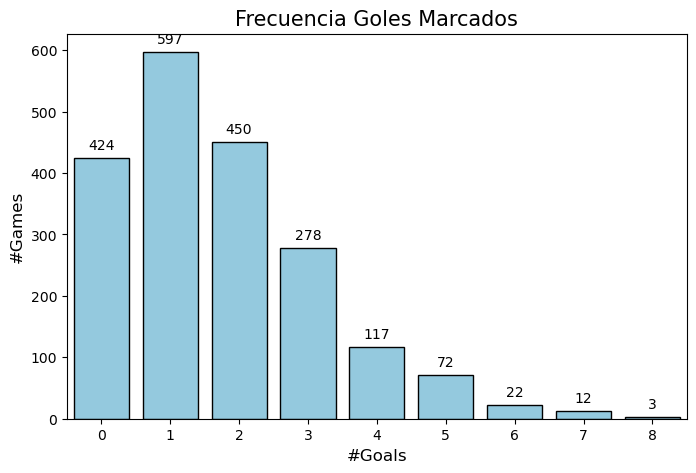

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

plt.figure(figsize=(8, 5))

# Usamos countplot en lugar de histplot para datos discretos
# Esto asegura que cada columna esté alineada exactamente con el número de goles
ax = sns.countplot(data=df_final, x='Goals', color='skyblue', edgecolor='black')

# Añadir etiquetas de cantidad sobre cada barra para mayor claridad
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')
    
plt.title('Frecuencia Goles Marcados', fontsize=15)
plt.xlabel('#Goals', fontsize=12)
plt.ylabel('#Games', fontsize=12)
plt.show()

Validación gráfica otras variables

c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use 

<Figure size 1200x800 with 0 Axes>

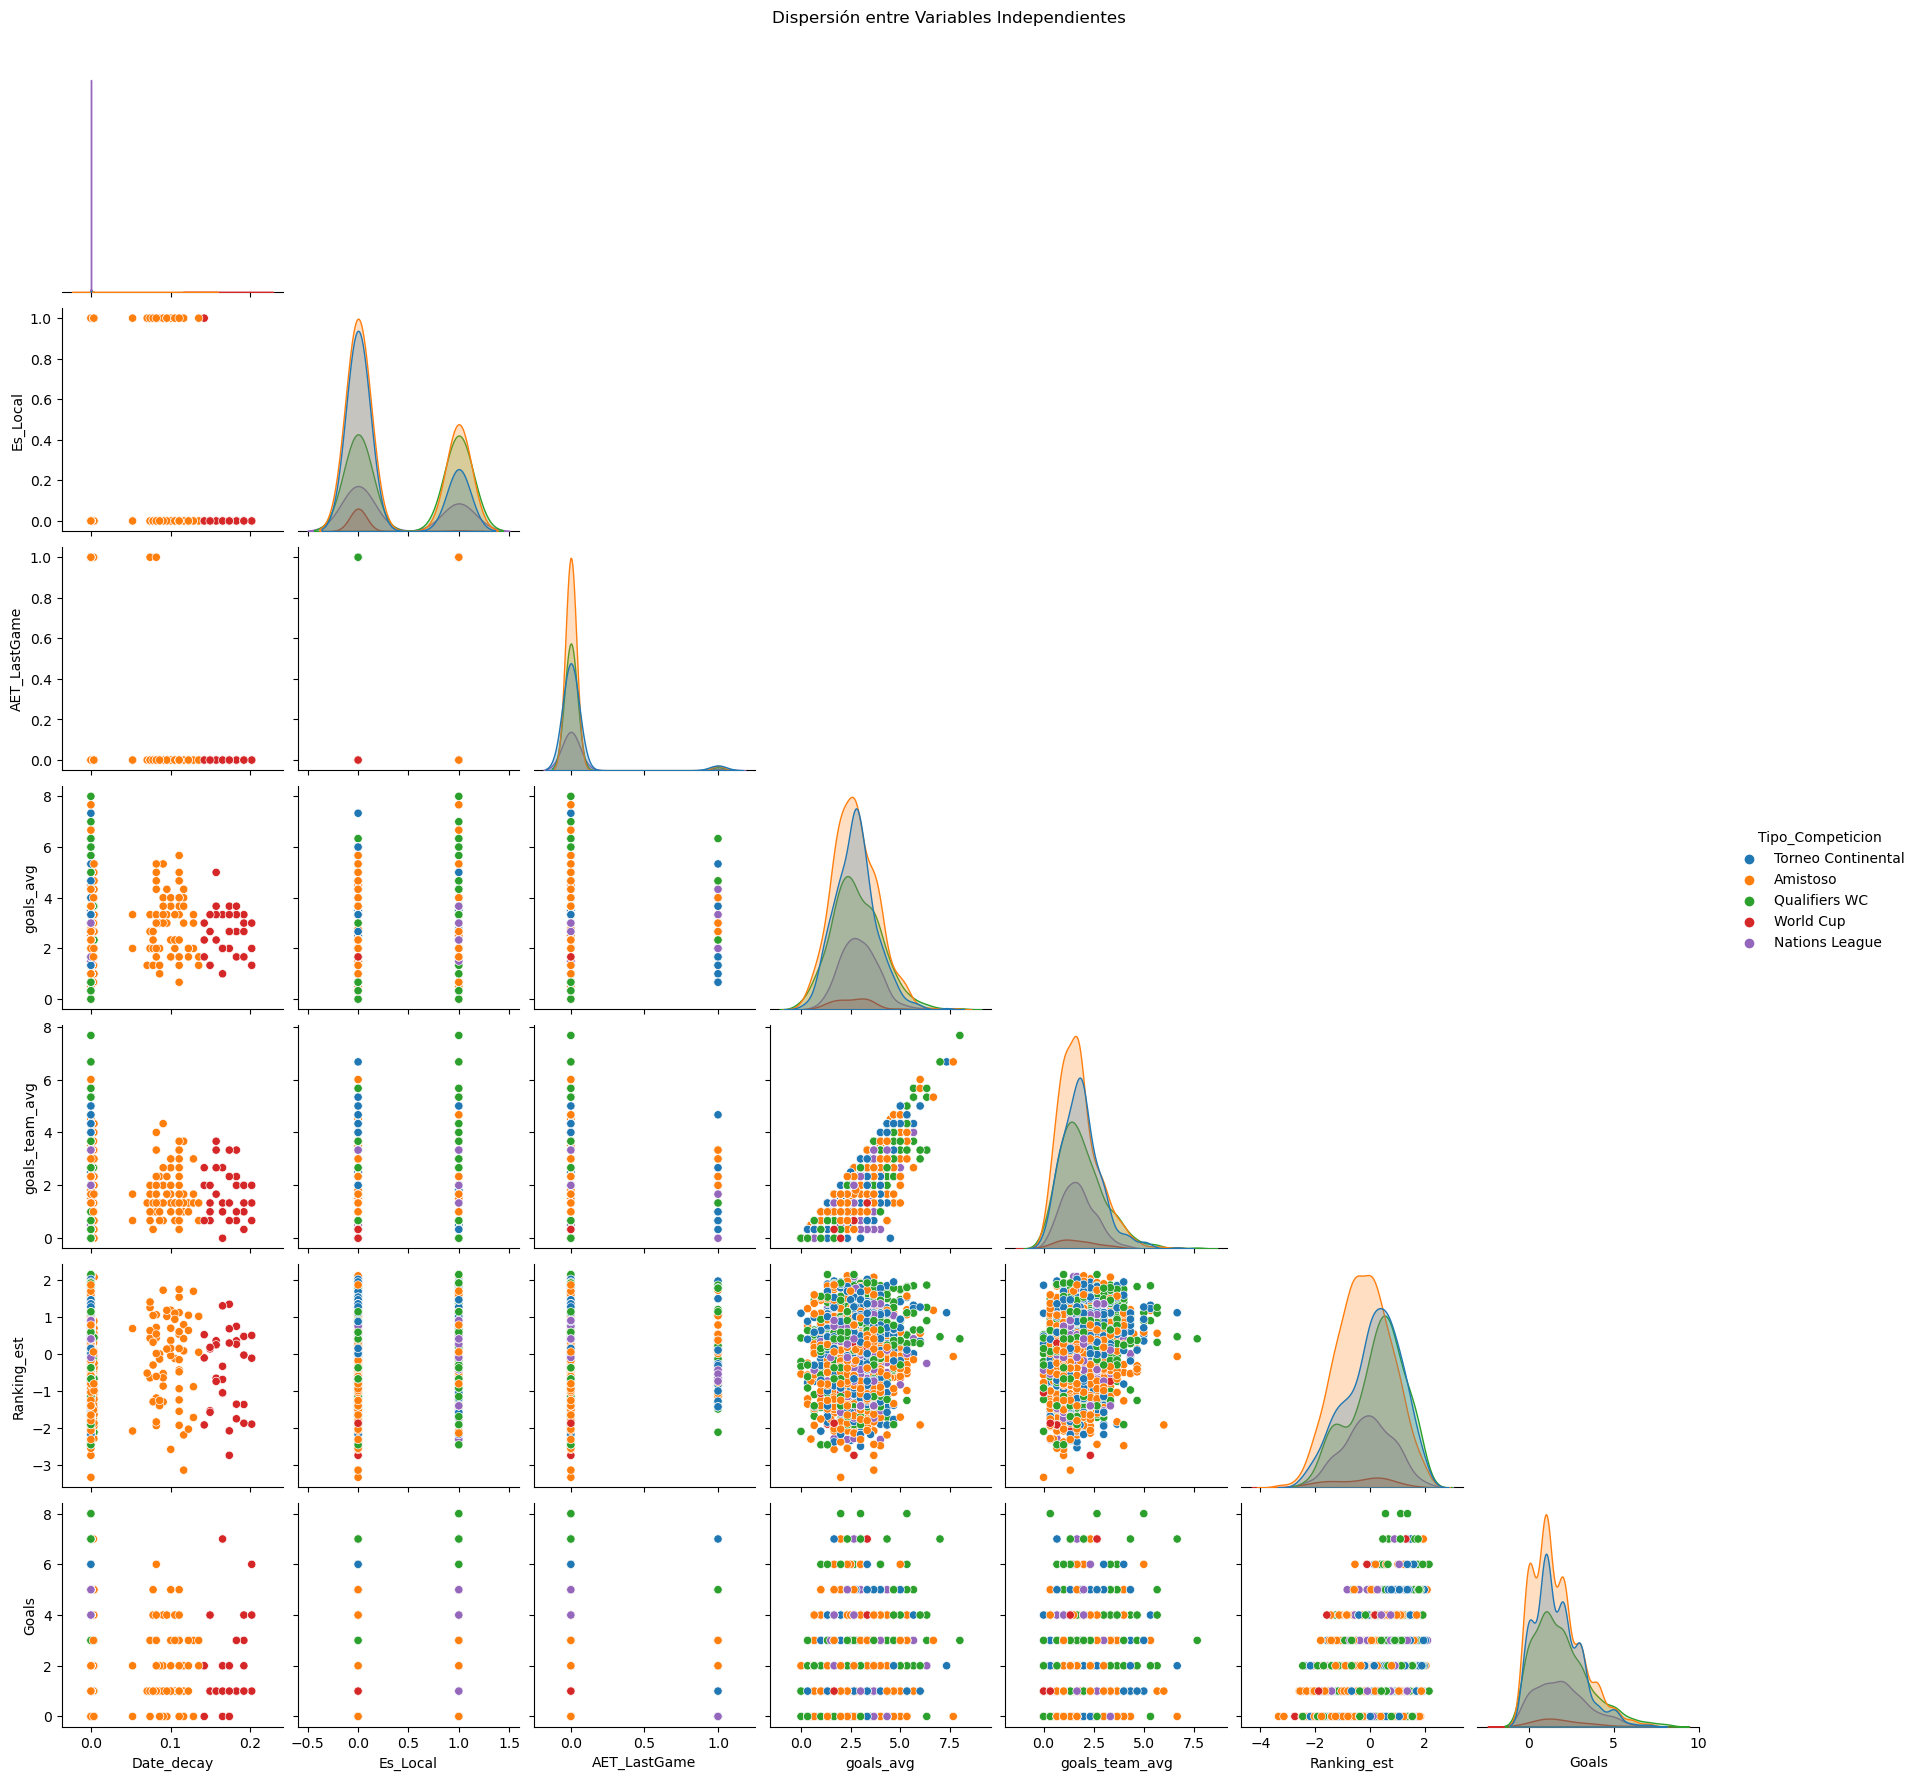

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos las variables numéricas que usaremos en el modelo
variables_independientes = ['Date_decay',
    'Tipo_Competicion', 'Es_Local', 'AET_LastGame', 'goals_avg',
    'goals_team_avg', 'Ranking_est', 'Goals']

# Creamos el pairplot
plt.figure(figsize=(12, 8))
sns.pairplot(df_final[variables_independientes], hue='Tipo_Competicion', diag_kind='kde', corner=True)
plt.suptitle('Dispersión entre Variables Independientes', y=1.02)
plt.show()

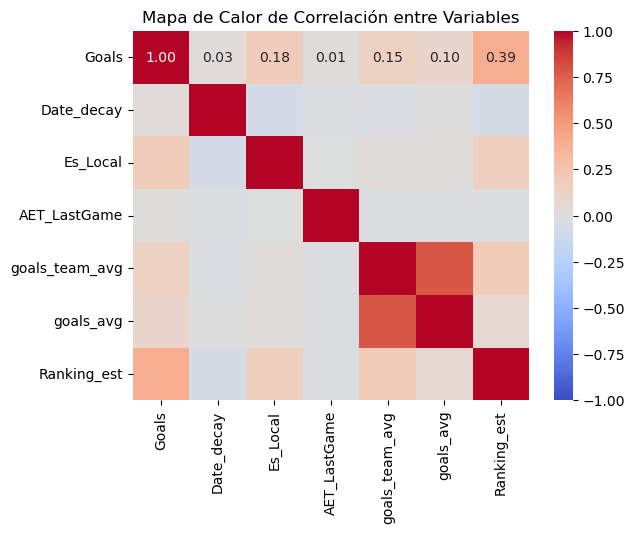

In [15]:
variables_independientes_2 = ['Goals', 'Date_decay','Es_Local', 'AET_LastGame', 'goals_team_avg', 'goals_avg', 'Ranking_est']

# Calculamos la matriz de correlación
correlacion = df_final[variables_independientes_2].corr()

# Creamos el mapa de calor
#plt.figure(figsize=(9, 6))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Mapa de Calor de Correlación entre Variables')
plt.show()

Modelación

                 Generalized Linear Model Regression Results                  
Dep. Variable:             Goals_team   No. Observations:                 1975
Model:                            GLM   Df Residuals:                     1965
Model Family:        NegativeBinomial   Df Model:                            9
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3448.0
Date:                Fri, 19 Jun 2026   Deviance:                       1079.2
Time:                        12:01:10   Pearson chi2:                     765.
No. Iterations:                     5   Pseudo R-squ. (CS):            0.08346
Covariance Type:            nonrobust                                         
                                                coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


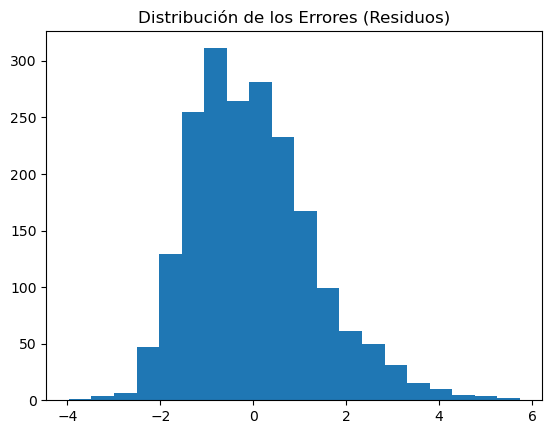

In [16]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Definición del modelo Poisson
# Lambda es la tasa de goles esperados
# La fórmula usa log-link por defecto: log(mu) = beta0 + beta1*X1 + ...

formula = "Goals_team ~ Es_Local + C(Tipo_Competicion) + goals_team_avg + goals_avg + Ranking_est + Date_decay"

# Ajuste del modelo
model_1 = smf.glm(formula=formula, data=df_final, family=sm.families.NegativeBinomial()).fit()
                #var_weights=df_final['Peso_Partido']).fit()

df_model_1 = df_final.copy()

df_model_1['Prediccion'] = model_1.predict(df_model_1)
df_model_1['Error'] = df_model_1['Goals_team'] - df_model_1['Prediccion']

print(model_1.summary())
# Visualizar si el error está centrado en 0
import matplotlib.pyplot as plt
plt.hist(df_model_1['Error'], bins=20)
plt.title("Distribución de los Errores (Residuos)")
plt.show()

Modelo sin variables Redundantes

                 Generalized Linear Model Regression Results                  
Dep. Variable:             Goals_team   No. Observations:                 1975
Model:                            GLM   Df Residuals:                     1969
Model Family:        NegativeBinomial   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3450.0
Date:                Fri, 19 Jun 2026   Deviance:                       1083.2
Time:                        12:01:11   Pearson chi2:                     771.
No. Iterations:                     5   Pseudo R-squ. (CS):            0.08162
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.2538      0.081      3.

c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


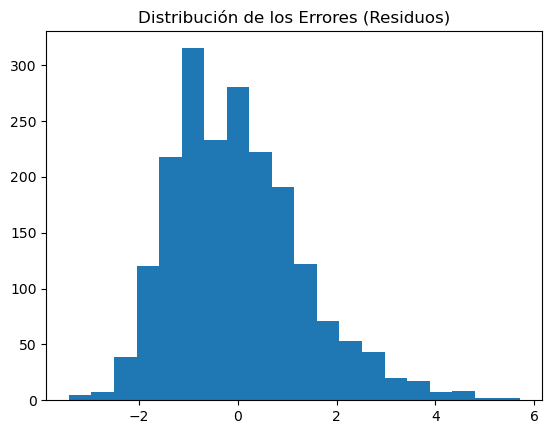

In [17]:
formula = "Goals_team ~ Es_Local + goals_avg + goals_team_avg + Ranking_est + Date_decay"

# Ajuste del modelo
model_2 = smf.glm(formula=formula, data=df_final, family=sm.families.NegativeBinomial()).fit()
            #var_weights=df_final['Peso_Partido']).fit()

df_model_2 = df_final.copy()

df_model_2['Prediccion'] = model_2.predict(df_model_2)
df_model_2['Error'] = df_model_2['Goals_team'] - df_model_2['Prediccion']

print(model_2.summary())
# Visualizar si el error está centrado en 0
import matplotlib.pyplot as plt
plt.hist(df_model_2['Error'], bins=20)
plt.title("Distribución de los Errores (Residuos)")
plt.show()

Modelo sin intercepto

c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:             Goals_team   No. Observations:                 1975
Model:                            GLM   Df Residuals:                     1970
Model Family:        NegativeBinomial   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3450.1
Date:                Fri, 19 Jun 2026   Deviance:                       1083.4
Time:                        12:01:11   Pearson chi2:                     770.
No. Iterations:                     5   Pseudo R-squ. (CS):            0.08152
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.2779      0.064      4.

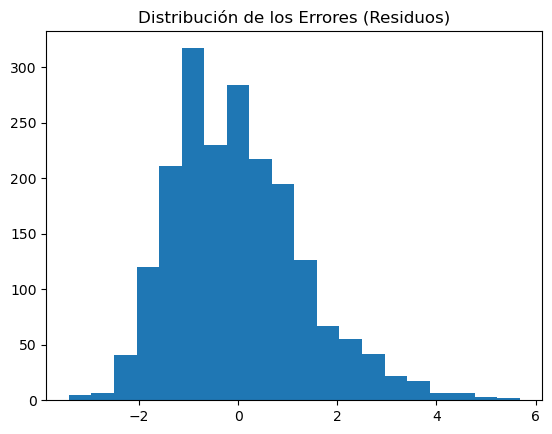

In [18]:
formula = "Goals_team ~ Es_Local + Ranking_est + goals_team_avg + Date_decay"

# Ajuste del modelo
model_3 = smf.glm(formula=formula, data=df_final, family=sm.families.NegativeBinomial()).fit()
            #var_weights=df_final['Peso_Partido']).fit()

df_model_3 = df_final.copy()

df_model_3['Prediccion'] = model_3.predict(df_model_3)
df_model_3['Error'] = df_model_3['Goals_team'] - df_model_3['Prediccion']

print(model_3.summary())
# Visualizar si el error está centrado en 0
import matplotlib.pyplot as plt
plt.hist(df_model_3['Error'], bins=20)
plt.title("Distribución de los Errores (Residuos)")
plt.show()

Comparacion entre modelos

In [19]:
print(f"M1: {model_1.aic}")
print(f"M2: {model_2.aic}")
print(f"M3: {model_3.aic}")

###Model 2 /// Less AIC

M1: 6915.954605846595
M2: 6911.913766122187
M3: 6910.135716105526


In [20]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(df_model_3['Goals'], df_model_3['Prediccion'])
print(f"Error promedio: {mae:.2f} goles por partido")

Error promedio: 1.05 goles por partido


In [21]:
# Identificar partidos donde el error es mayor a 2 goles
df_model_3['Abs_Error'] = abs(df_model_3['Error'])
fallos_graves = df_model_3.sort_values(by='Abs_Error', ascending=False).head(10)
print(fallos_graves[['Team', 'Opponent', 'Goals_team', 'Prediccion', 'Abs_Error','Ranking_diff']])

     Team Opponent  Goals_team  Prediccion  Abs_Error  Ranking_diff
256   NZL      VAN         8.0    2.317612   5.682388    287.510892
597   QAT      AFG         8.0    2.617930   5.382070    470.744174
819   ALG      GUA         7.0    1.828709   5.171291    320.493849
1236  CUW      BER         7.0    1.872317   5.127683    311.942393
257   NZL      SAM         8.0    3.221796   4.778204    413.633591
1702  ESP      GEO         7.0    2.269380   4.730620    500.771984
1608  GER      BIH         7.0    2.428812   4.571188    362.368295
1477  CZE      MLT         7.0    2.473825   4.526175    488.692501
1365  AUT      TUR         6.0    1.534658   4.465342     33.389825
1937  CAN      HON         6.0    1.574457   4.425543    193.163121


Gráfico de Ranking_diff

c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


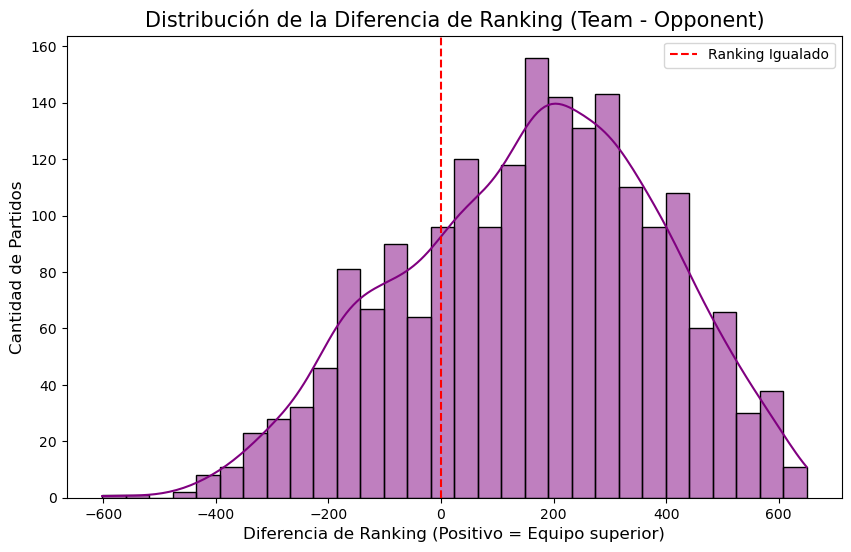

In [22]:
plt.figure(figsize=(10, 6))

# Histograma con KDE para ver la distribución
sns.histplot(df_final['Ranking_diff'], kde=True, bins=30, color='purple', edgecolor='black')

# Línea vertical en 0 (Equipos de igual ranking)
plt.axvline(0, color='red', linestyle='--', label='Ranking Igualado')

plt.title('Distribución de la Diferencia de Ranking (Team - Opponent)', fontsize=15)
plt.xlabel('Diferencia de Ranking (Positivo = Equipo superior)', fontsize=12)
plt.ylabel('Cantidad de Partidos', fontsize=12)
plt.legend()
plt.show()

API Partidos FIFA

In [23]:
import pandas as pd
import json
import requests

# 1. Obtener los próximos partidos (vía API o descarga directa)
url_g = "https://worldcup26.ir/get/games"
url_t = "https://worldcup26.ir/get/teams"
url_s = "https://worldcup26.ir/get/stadiums"
response = requests.get(url_g)
calendario = response.json()
response = requests.get(url_t)
teams = response.json()
response = requests.get(url_s)
stadiums = response.json()

def crear_diccionario_estadios(data):
    stadium_dict = {}
    
    for s in data['stadiums']:
        # Concatenación: Nombre, Ciudad, País
        info_completa = f"{s['name_en']}, {s['city_en']}, {s['country_en']}"
        
        # Asignar al diccionario usando el ID como llave
        stadium_dict[s['id']] = info_completa
        
    return stadium_dict

# Uso:
dict_estadios = crear_diccionario_estadios(stadiums)
id_to_fifa = {team['id']: team['fifa_code'] for team in teams['teams']}

In [25]:
def preparar_calendario(lista_partidos):
    rows = []
    for partido in lista_partidos:
        # Registro 1: Perspectiva del Local
        rows.append({
            'Team_id': partido['home_team_id'],
            'Opponent_id': partido['away_team_id'],
            'Date': partido['local_date'],
            'home_score' : partido['home_score'],
            'away_score' : partido['away_score'],
            'stadium_id' : partido['stadium_id']
        })
        # Registro 2: Perspectiva del Visitante
        rows.append({
            'Team_id': partido['away_team_id'],
            'Opponent_id': partido['home_team_id'],
            'Date': partido['local_date'],
            'home_score' : partido['away_score'],
            'away_score' : partido['home_score'],
            'stadium_id' : partido['stadium_id']            
        })
    
    return pd.DataFrame(rows)

# df_futuro tendrá el doble de filas que partidos haya en el JSON
df_futuro = preparar_calendario(calendario['games'])
df_futuro = df_futuro[df_futuro['Team_id'] != "0"].copy()
df_futuro = calcular_decaimiento_exponencial(df_futuro)
df_futuro['Team'] = df_futuro['Team_id'].map(id_to_fifa)
df_futuro['Game_type'] = 'World Cup'
df_futuro['Venue'] = df_futuro['stadium_id'].map(dict_estadios)
df_futuro['Opponent'] = df_futuro['Opponent_id'].map(id_to_fifa)
df_futuro['Es_Local'] = np.where(df_futuro['Team'].isin(['CAN','MEX','USA']), 1, 0)

df_futuro['Ranking_Team'] = df_futuro['Team'].map(ranking_dict)
df_futuro['Ranking_Opponent'] = df_futuro['Opponent'].map(ranking_dict)
df_futuro['Ranking_diff'] = df_futuro['Ranking_Team'] - df_futuro['Ranking_Opponent']
df_futuro['Ranking_est'] = scaler.transform(df_futuro[['Ranking_diff']])
df_futuro['Peso_Partido'] = df_futuro['Game_type'].apply(asignar_peso)


In [26]:
df_ant = df_final[df_final['Game_type']!='World Cup'].sort_values(['Team', 'Date']).groupby('Team').tail(10)
df_act = df_futuro[df_futuro['Date']< pd.Timestamp.now()-pd.Timedelta(hours=3)].rename(
    columns={'home_score':'Goals_team', 'away_score':'Goals_opponent'}
)

df_act['Goals_team'] = pd.to_numeric(df_act['Goals_team'], errors='coerce')
df_act['Goals_opponent'] = pd.to_numeric(df_act['Goals_opponent'], errors='coerce')

df_mma = pd.concat([df_ant, df_act]).sort_values(['Team', 'Date']).groupby('Team').tail(mma)

df_mma['total_goals'] = df_mma['Goals_team'] + df_mma['Goals_opponent']
metricas_recientes = df_mma.groupby('Team').agg({'Goals_team': 'mean','total_goals': 'mean'}).rename(
    columns={'total_goals':'goals_avg', 'Goals_team':'goals_team_avg'})
metricas_recientes.sample(3)

df_pred = df_futuro[df_futuro['Date']>= pd.Timestamp.now()-pd.Timedelta(hours=3)].copy()
df_pred = df_pred.merge(metricas_recientes, left_on='Team', right_index=True, how='left')

In [31]:
df_pred['Prediccion_Goles'] = model_3.predict(df_pred)

# 4. Resultado (Redondeo opcional para marcador lógico)
# Nota: Puedes mantener el decimal para tener una "probabilidad" más fina
df_pred['Goles_Estimados'] = df_pred['Prediccion_Goles'].round(0).astype(int)

In [33]:
filtro = df_pred['Date'].dt.date == pd.Timestamp('2026-06-19').date()
df_hoy = df_pred[filtro]
print(df_hoy[['Team', 'Opponent', 'Goles_Estimados']])

   Team Opponent  Goles_Estimados
56  BRA      HAI                4
57  HAI      BRA                1
58  SCO      MAR                1
59  MAR      SCO                2
60  USA      AUS                3
61  AUS      USA                2
62  TUR      PAR                2
63  PAR      TUR                2


    Team Opponent  Goles_Estimados
56   BRA      HAI                4
57   HAI      BRA                1
58   SCO      MAR                1
59   MAR      SCO                2
60   USA      AUS                3
..   ...      ...              ...
139  ARG      JOR                5
140  COL      POR                2
141  POR      COL                2
142  COD      UZB                2
143  UZB      COD                2

[88 rows x 3 columns]


In [ ]:
df_final.sample()

,Team,Date,Tipo_Partido,Venue,Condition,Oponente,Goals_team,Goals_opponent,Resultado_Original,Penalties,...,Es_Local,AET_LastGame,goals_team_avg,goals_avg,Peso_Partido,Ranking_Team,Ranking_Opponent,Ranking_diff,Goals,Ranking_est
1516,ENG,2024-06-16,UEFA Euro 2024 Group C,"Gelsenkirchen , Germany",N,Serbia,1.0,0.0,0–1,False,...,0,0,1.666667,2.666667,0.65,1847.677458,1502.133186,345.544272,1,0.822925


In [ ]:
modelo_zinb = sm.ZeroInflatedNegativeBinomialP(
    endog=df_final['Goals'], 
    exog=df_final[['Es_Local', 'Ranking_est', 'goals_avg', 'goals_team_avg', 'Date_decay']], 
    exog_infl=df_final[['goals_avg', 'goals_team_avg']] 
).fit()

print(modelo_zinb.summary())

c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\statsmodels\discrete\discrete_model.py:3935: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\statsmodels\discrete\discrete_model.py:3936: RuntimeWarning: invalid value encountered in log
  (y + a1) * np.log(a2))
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\statsmodels\discrete\discrete_model.py:3972: RuntimeWarning: invalid value encountered in log
  dgterm = dgpart + np.log(a1 / a2) + 1 - a3 / a2
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\statsmodels\discrete\discrete_model.py:2383: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\statsmodels\discrete\discrete_model.py:4325: RuntimeWarning: overflow encountered in exp
  return np.exp(linpred)
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\statsmodels\discr

         Current function value: nan
         Iterations: 1
         Function evaluations: 112
         Gradient evaluations: 112
                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                             Goals   No. Observations:                 1975
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                     1970
Method:                                      MLE   Df Model:                            4
Date:                          vie, 19 jun. 2026   Pseudo R-squ.:                     nan
Time:                                   00:51:45   Log-Likelihood:                    nan
converged:                                 False   LL-Null:                           nan
Covariance Type:                       nonrobust   LLR p-value:                       nan
                             coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------

c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\statsmodels\discrete\discrete_model.py:2383: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\statsmodels\discrete\discrete_model.py:3935: RuntimeWarning: divide by zero encountered in log
  a1 * np.log(a1) + y * np.log(mu) -
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\statsmodels\discrete\discrete_model.py:3935: RuntimeWarning: invalid value encountered in multiply
  a1 * np.log(a1) + y * np.log(mu) -
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\statsmodels\discrete\discrete_model.py:3969: RuntimeWarning: invalid value encountered in divide
  a4 = p * a1 / mu
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\statsmodels\discrete\discrete_model.py:3977: RuntimeWarning: divide by zero encountered in divide
  y / mu)
c:\Users\sarud\miniconda3\envs\ETL_update\Lib\site-packages\statsmodels\discrete\discrete_mod

In [ ]:
df_pred

,Team_id,Opponent_id,Date,home_score,away_score,stadium_id,Final_days,Date_decay,Team,Game_type,...,Es_Local,Ranking_Team,Ranking_Opponent,Ranking_diff,Ranking_est,Peso_Partido,goals_team_avg,goals_avg,Prediccion_Goles,Goles_Estimados
56,9,11,2026-06-19 21:00:00,0,0,10,30,0.223130,BRA,World Cup,...,0,1765.340396,1277.668371,487.672025,1.446407,0.9,3.000000,4.333333,3.791199,4
57,11,9,2026-06-19 21:00:00,0,0,10,30,0.223130,HAI,World Cup,...,0,1277.668371,1765.340396,-487.672025,-2.832206,0.9,1.000000,1.333333,0.806802,1
58,12,10,2026-06-19 18:00:00,0,0,9,30,0.223130,SCO,World Cup,...,0,1518.768484,1755.616133,-236.847649,-1.731896,0.9,3.000000,3.333333,1.317647,1
59,10,12,2026-06-19 18:00:00,0,0,9,30,0.223130,MAR,World Cup,...,0,1755.616133,1518.768484,236.847649,0.346098,0.9,2.000000,2.666667,2.470660,2
60,13,15,2026-06-19 12:00:00,0,0,14,30,0.223130,USA,World Cup,...,1,1688.534820,1605.607419,82.927401,-0.329116,0.9,2.666667,4.333333,2.531904,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,37,40,2026-06-27 21:00:00,0,0,4,22,0.332871,ARG,World Cup,...,0,1889.062265,1372.286342,516.775923,1.574079,0.9,2.666667,2.666667,4.686208,5
140,44,41,2026-06-27 19:30:00,0,0,8,22,0.332871,COL,World Cup,...,0,1712.604162,1755.093610,-42.489448,-0.879291,0.9,2.666667,3.333333,2.072676,2
141,41,44,2026-06-27 19:30:00,0,0,8,22,0.332871,POR,World Cup,...,0,1755.093610,1712.604162,42.489448,-0.506508,0.9,1.666667,2.666667,2.204431,2
142,42,43,2026-06-27 19:30:00,0,0,7,22,0.332871,COD,World Cup,...,0,1487.183182,1444.481764,42.701418,-0.505578,0.9,0.666667,1.333333,2.071870,2
